In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# ---- inputs ----
CHUNK    = "../momentum_exp/data/chunk_000.npz"      # path from momentum_exp/ notebook; adjust if needed
ETA      = 1.0
DX       = 0.5
FONTSIZE = 16

d = np.load(CHUNK)
times, t_hat, tau = d["times"], float(d["t_hat"]), float(d["tau"])

corr = []
for i, t in enumerate(times):
    phi, pi = d["phi"][:, i].astype(np.float64), d["pi"][:, i].astype(np.float64)
    eps = t * t_hat / tau                                              # eps = t / tau
    lap = (np.roll(phi, 1, -1) + np.roll(phi, -1, -1) +
           np.roll(phi, 1, -2) + np.roll(phi, -1, -2) - 4 * phi) / DX**2   # same Laplacian as kz_2d
    pi_od = (lap - 0.5 * (phi**3 - eps * phi)) / ETA                   # overdamped estimate of pi
    corr.append(np.corrcoef(pi.ravel(), pi_od.ravel())[0, 1])
    print(f"t = {t:4.1f} t_hat:  corr(pi, pi_od) = {corr[-1]:.3f}")

plt.figure(figsize=(8, 5.5))
plt.plot(times, corr, "o-", ms=9, lw=2)
plt.axhline(1, color="grey", lw=1)
plt.xlabel(r"time $t/\hat t$", fontsize=FONTSIZE)
plt.ylabel(r"corr$(\pi,\ \pi_\mathrm{od})$", fontsize=FONTSIZE)
plt.title(r"is momentum slaved to the field? ($\tau_Q = 4$)", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../momentum_exp/data/chunk_000.npz'

In [4]:
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

In [7]:
import os
print("notebook is running in:", os.getcwd())
print("json files found:", len(glob.glob(f"{RESULTS}/*.json")))

notebook is running in: /home/kristian/BU/MachineLearningKZ/momentum_exp
json files found: 0


    t  best ep phi  best ep phi_pi
    0        12/29           19/29
  0.5        21/29           21/29
    1        11/29           27/29
    2        29/29           28/29
    3        29/29           29/29
    4        29/29           27/29
    5        27/29           28/29
    6        26/29           28/29


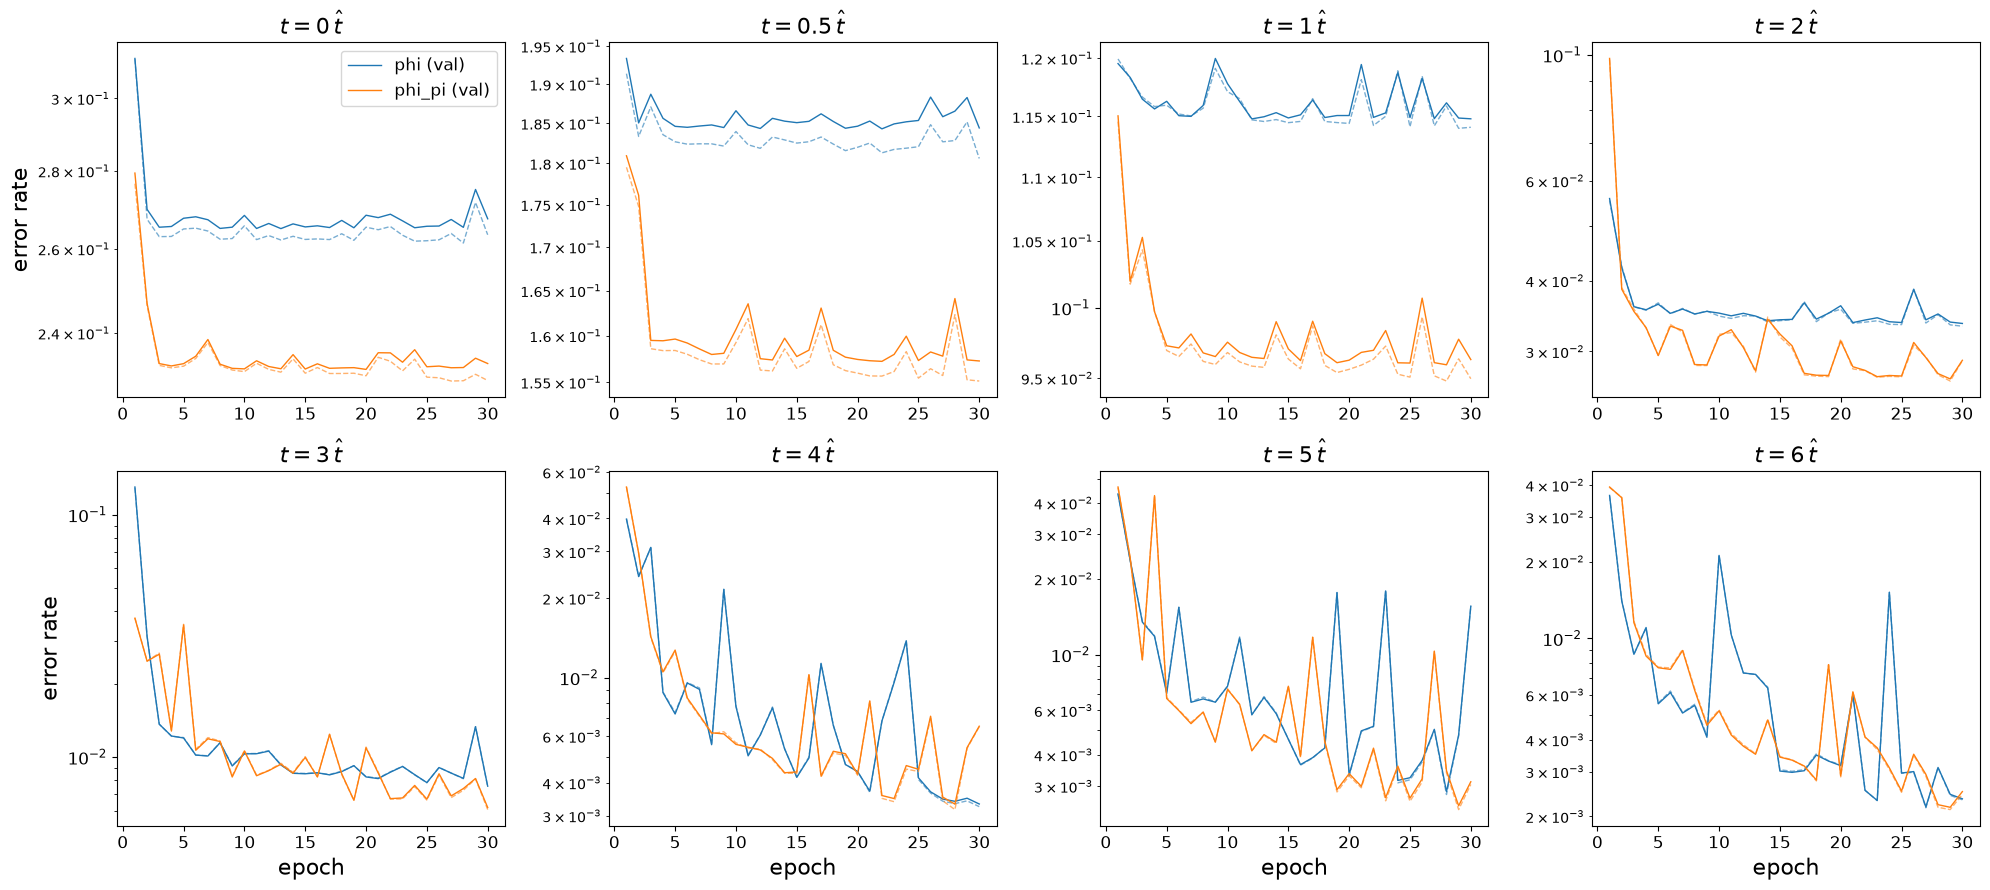

In [9]:
# ---- inputs ----
RESULTS  = "results"                   # relative to momentum_exp/
FONTSIZE = 16

# load every run: runs[t][channels] = json contents
runs = {}
for f in glob.glob(f"{RESULTS}/*.json"):
    r = json.load(open(f))
    runs.setdefault(r["t"], {})[r["channels"]] = r
times = sorted(runs)

# ---- table: best epoch by validation accuracy ----
print(f"{'t':>5} {'best ep phi':>12} {'best ep phi_pi':>15}")
for t in times:
    be = {ch: int(np.argmax(np.array(runs[t][ch]["history"])[:, 3])) for ch in ("phi", "phi_pi")}
    print(f"{t:>5g} {be['phi']:>9d}/29 {be['phi_pi']:>12d}/29")

# ---- learning curves ----
ncol = 4
nrow = int(np.ceil(len(times) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4.5 * nrow), squeeze=False)
for ax, t in zip(axes.ravel(), times):
    for ch, c in [("phi", "C0"), ("phi_pi", "C1")]:
        h  = np.array(runs[t][ch]["history"])            # train_loss, val_loss, train_acc, val_acc
        ep = np.arange(1, len(h) + 1)
        ax.semilogy(ep, 1 - h[:, 3], "-",  color=c, lw=1, label=f"{ch} (val)")
        ax.semilogy(ep, 1 - h[:, 2], "--", color=c, lw=1, alpha=0.6)
    ax.set_title(rf"$t = {t:g}\,\hat t$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 4)
for ax in axes.ravel()[len(times):]:
    ax.axis("off")
for ax in axes[-1]:
    ax.set_xlabel("epoch", fontsize=FONTSIZE)
for ax in axes[:, 0]:
    ax.set_ylabel("error rate", fontsize=FONTSIZE)
axes[0, 0].legend(fontsize=FONTSIZE - 4)
plt.tight_layout()
plt.savefig("learning_curves_momentum.png", dpi=150)
plt.show()

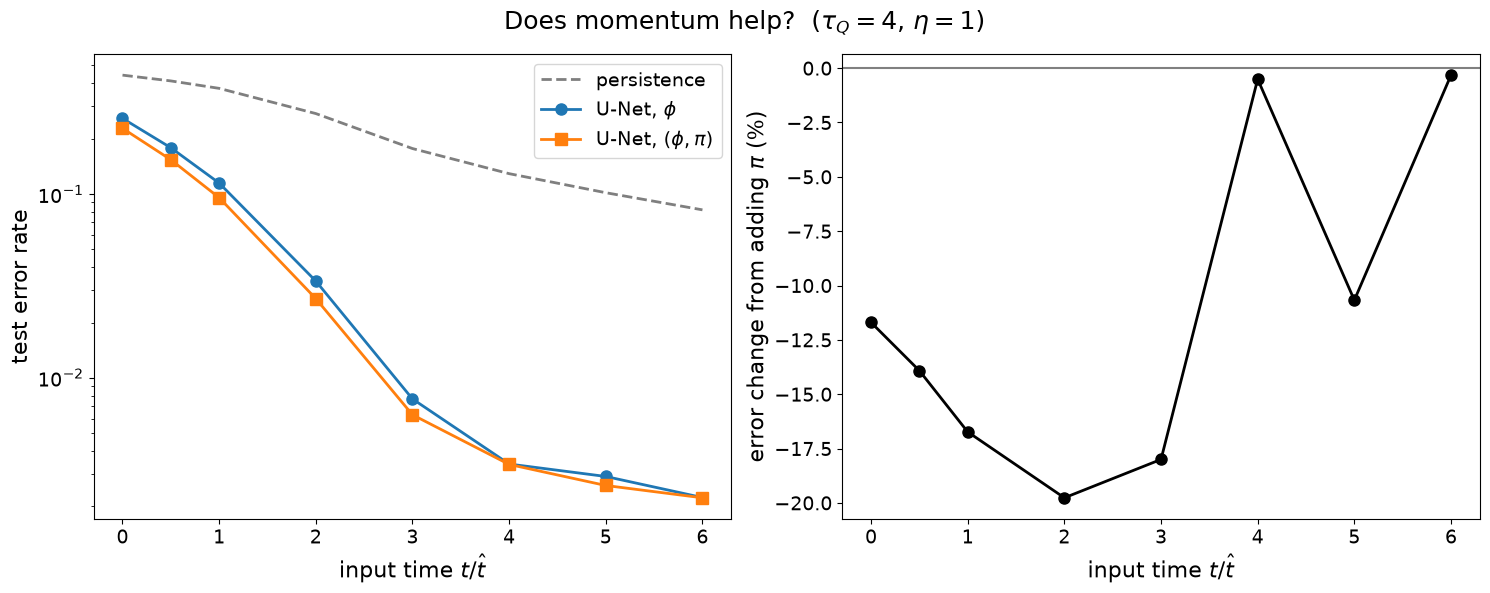

In [10]:
# ---- inputs ----
FONTSIZE = 16

pers  = np.array([1 - runs[t]["phi"]["baseline"]     for t in times])
e_phi = np.array([1 - runs[t]["phi"]["test_acc"]     for t in times])
e_pi  = np.array([1 - runs[t]["phi_pi"]["test_acc"]  for t in times])

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].semilogy(times, pers,  "--",  color="C7", lw=2, label="persistence")
ax[0].semilogy(times, e_phi, "o-",  color="C0", lw=2, ms=8, label=r"U-Net, $\phi$")
ax[0].semilogy(times, e_pi,  "s-",  color="C1", lw=2, ms=8, label=r"U-Net, $(\phi, \pi)$")
ax[0].set_ylabel("test error rate", fontsize=FONTSIZE)
ax[0].legend(fontsize=FONTSIZE - 2)

ax[1].plot(times, 100 * (e_pi - e_phi) / e_phi, "o-", color="k", lw=2, ms=8)
ax[1].axhline(0, color="grey", lw=1.5)
ax[1].set_ylabel(r"error change from adding $\pi$ (%)", fontsize=FONTSIZE)

for a in ax:
    a.set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
    a.tick_params(labelsize=FONTSIZE - 2)
fig.suptitle(r"Does momentum help?  ($\tau_Q = 4$, $\eta = 1$)", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig("momentum_result.png", dpi=150)
plt.show()

In [12]:
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

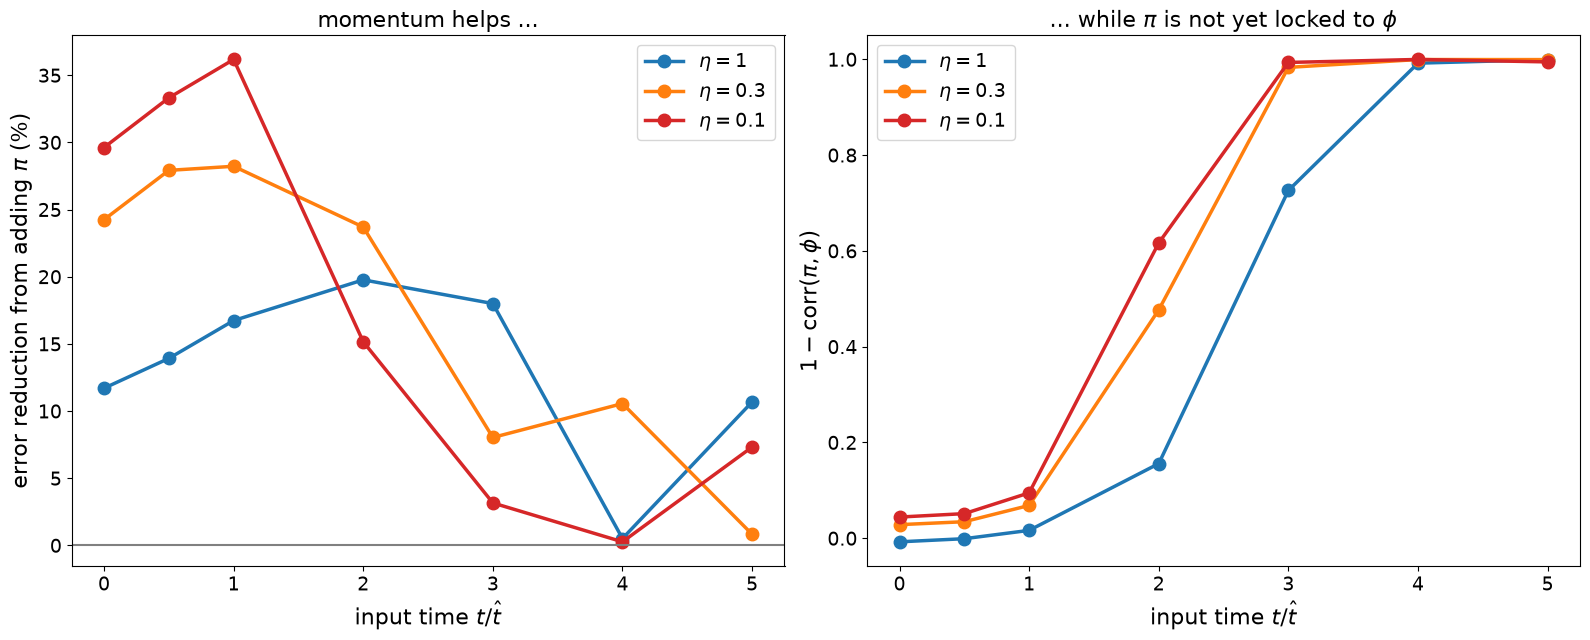

In [21]:
# ---- inputs ----
ETAS     = ["1", "0.3", "0.1"]
T_MAX    = 5                            # last time shown (late times: saturation, not the crossover)
FONTSIZE = 16

colors = {"1": "C0", "0.3": "C1", "0.1": "C3"}
fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))

for eta in ETAS:
    # momentum gain from the training results
    runs = {}
    for f in glob.glob(f"results_eta{eta}/t*.json"):
        r = json.load(open(f))
        runs.setdefault(r["t"], {})[r["channels"]] = r
    ts   = sorted(t for t in runs if t <= T_MAX)
    gain = [100 * (1 - (1 - runs[t]["phi_pi"]["test_acc"]) / (1 - runs[t]["phi"]["test_acc"])) for t in ts]
    ax[0].plot(ts, gain, "o-", color=colors[eta], ms=9, lw=2.5, label=rf"$\eta = {eta}$")

    # how much of pi is NOT explained by phi
    c  = json.load(open(f"results_eta{eta}/corr.json"))
    tc = np.array(c["times"]); m = tc <= T_MAX
    ax[1].plot(tc[m],  np.array(c["corr"])[m], "o-", color=colors[eta], ms=9, lw=2.5, label=rf"$\eta = {eta}$")

ax[0].axhline(0, color="grey", lw=1.5)
ax[0].set_ylabel(r"error reduction from adding $\pi$ (%)", fontsize=FONTSIZE)
ax[0].set_title("momentum helps ...", fontsize=FONTSIZE)
ax[1].set_ylabel(r"$1 - \mathrm{corr}(\pi, \phi)$", fontsize=FONTSIZE)
ax[1].set_title(r"... while $\pi$ is not yet locked to $\phi$", fontsize=FONTSIZE)
for a in ax:
    a.set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
    a.tick_params(labelsize=FONTSIZE - 2)
    a.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.savefig("momentum_vs_damping.png", dpi=150)
plt.show()

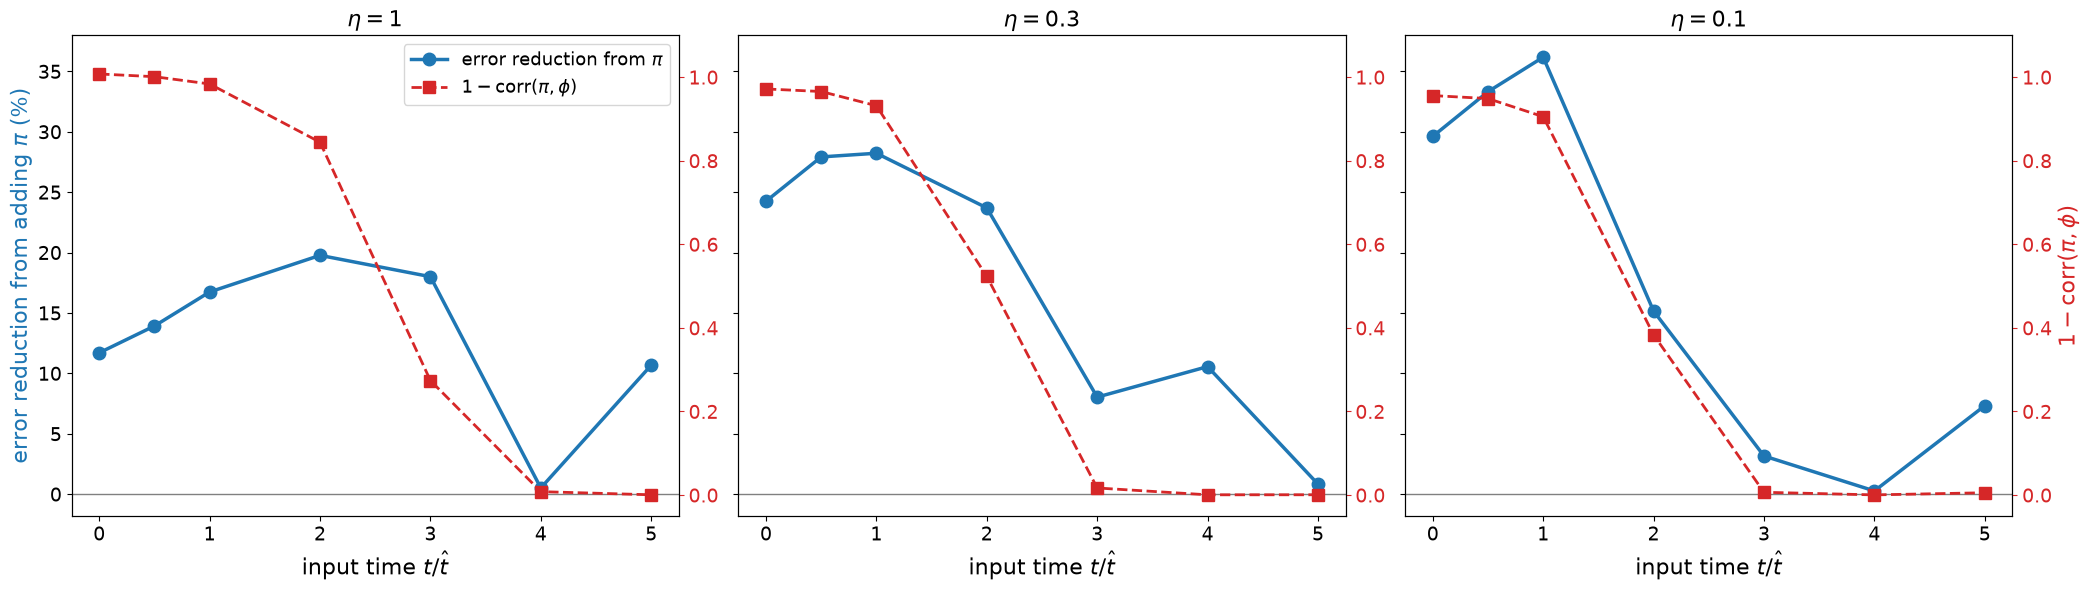

In [23]:
# ---- inputs ----
ETAS     = ["1", "0.3", "0.1"]
T_MAX    = 5                         # last time shown, units of t_hat
FONTSIZE = 16

fig, axes = plt.subplots(1, len(ETAS), figsize=(7 * len(ETAS), 6), sharey=True)

for ax, eta in zip(axes, ETAS):
    # momentum gain from the training results
    runs = {}
    for f in glob.glob(f"results_eta{eta}/t*.json"):
        r = json.load(open(f))
        runs.setdefault(r["t"], {})[r["channels"]] = r
    ts   = sorted(t for t in runs if t <= T_MAX)
    gain = [100 * (1 - (1 - runs[t]["phi_pi"]["test_acc"]) / (1 - runs[t]["phi"]["test_acc"])) for t in ts]

    # fraction of pi not explained by phi
    c  = json.load(open(f"results_eta{eta}/corr.json"))
    tc = np.array(c["times"])
    m  = tc <= T_MAX

    ax.plot(ts, gain, "o-", color="C0", ms=9, lw=2.5, label=r"error reduction from $\pi$")
    ax.axhline(0, color="grey", lw=1)
    ax.set_title(rf"$\eta = {eta}$", fontsize=FONTSIZE)
    ax.set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 2)

    ax2 = ax.twinx()
    ax2.plot(tc[m], 1 - np.array(c["corr"])[m], "s--", color="C3", ms=8, lw=2, label=r"$1 - \mathrm{corr}(\pi, \phi)$")
    ax2.set_ylim(-0.05, 1.1)
    ax2.tick_params(labelsize=FONTSIZE - 2, colors="C3")
    if eta == ETAS[-1]:
        ax2.set_ylabel(r"$1 - \mathrm{corr}(\pi, \phi)$", fontsize=FONTSIZE, color="C3")

axes[0].set_ylabel(r"error reduction from adding $\pi$ (%)", fontsize=FONTSIZE, color="C0")
h1, l1 = axes[0].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, fontsize=FONTSIZE - 3, loc="upper right")

plt.tight_layout()
plt.savefig("momentum_vs_correlation.png", dpi=150)
plt.show()

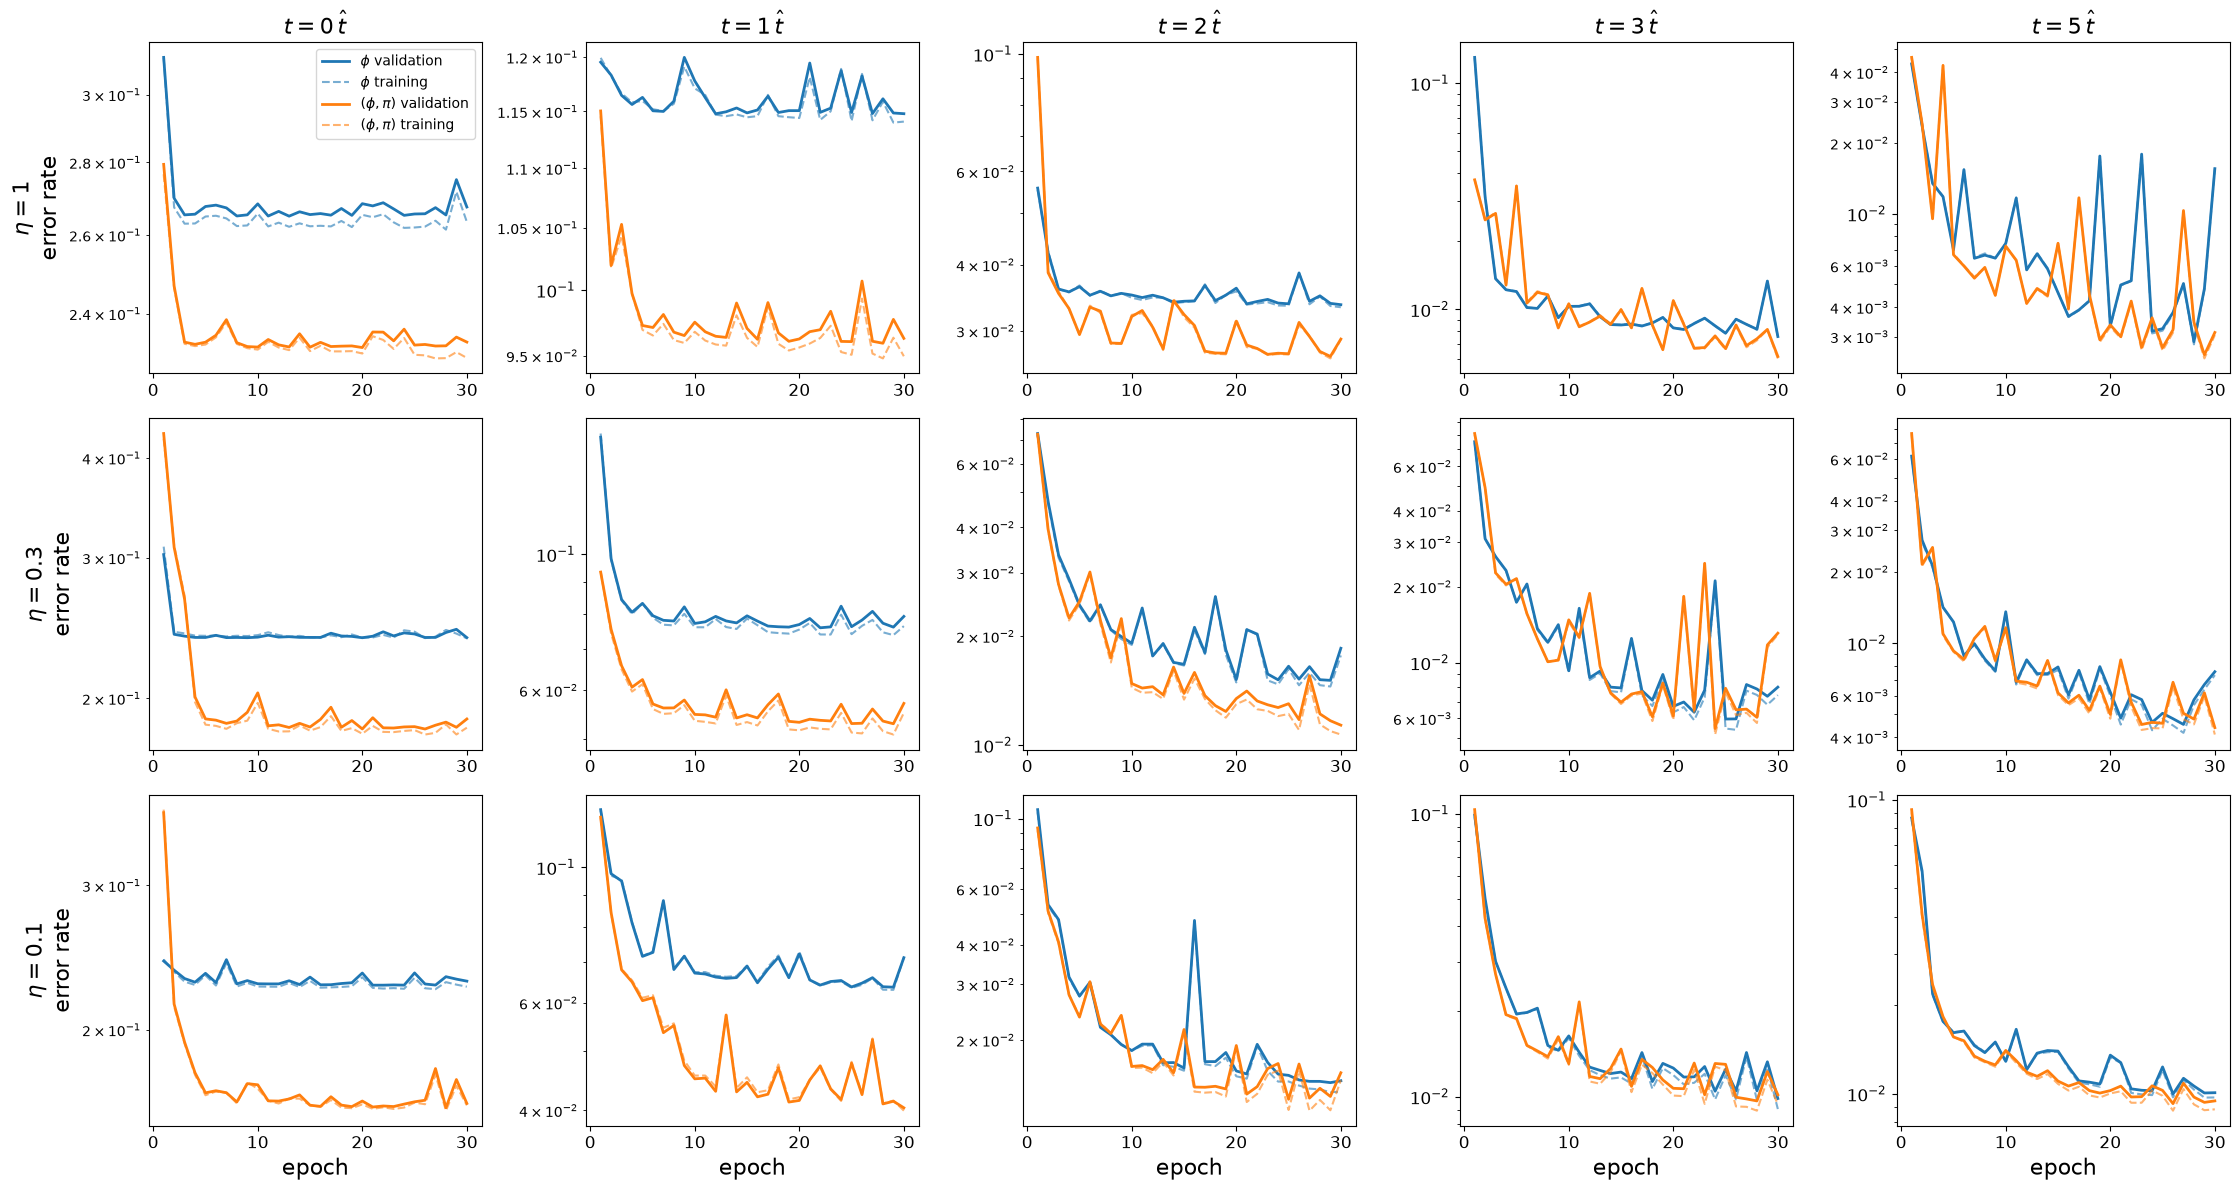

In [24]:
# ---- inputs ----
ETAS     = ["1", "0.3", "0.1"]
T_SHOW   = [0, 1, 2, 3, 5]              # input times to show, units of t_hat
FONTSIZE = 16

fig, axes = plt.subplots(len(ETAS), len(T_SHOW), figsize=(4.5 * len(T_SHOW), 4 * len(ETAS)), squeeze=False)

for row, eta in enumerate(ETAS):
    runs = {}
    for f in glob.glob(f"results_eta{eta}/t*.json"):
        r = json.load(open(f))
        runs.setdefault(r["t"], {})[r["channels"]] = r

    for col, t in enumerate(T_SHOW):
        ax = axes[row, col]
        for ch, c, lab in [("phi", "C0", r"$\phi$"), ("phi_pi", "C1", r"$(\phi, \pi)$")]:
            h  = np.array(runs[t][ch]["history"])          # columns: train_loss, val_loss, train_acc, val_acc
            ep = np.arange(1, len(h) + 1)
            ax.semilogy(ep, 1 - h[:, 3], "-",  color=c, lw=2, label=f"{lab} validation")
            ax.semilogy(ep, 1 - h[:, 2], "--", color=c, lw=1.5, alpha=0.6, label=f"{lab} training")
        ax.tick_params(labelsize=FONTSIZE - 4)
        if row == 0:
            ax.set_title(rf"$t = {t:g}\,\hat t$", fontsize=FONTSIZE)
        if row == len(ETAS) - 1:
            ax.set_xlabel("epoch", fontsize=FONTSIZE)
    axes[row, 0].set_ylabel(rf"$\eta = {eta}$" + "\nerror rate", fontsize=FONTSIZE)

axes[0, 0].legend(fontsize=FONTSIZE - 6)
plt.tight_layout()
plt.savefig("learning_curves_phi_vs_phipi.png", dpi=150)
plt.show()

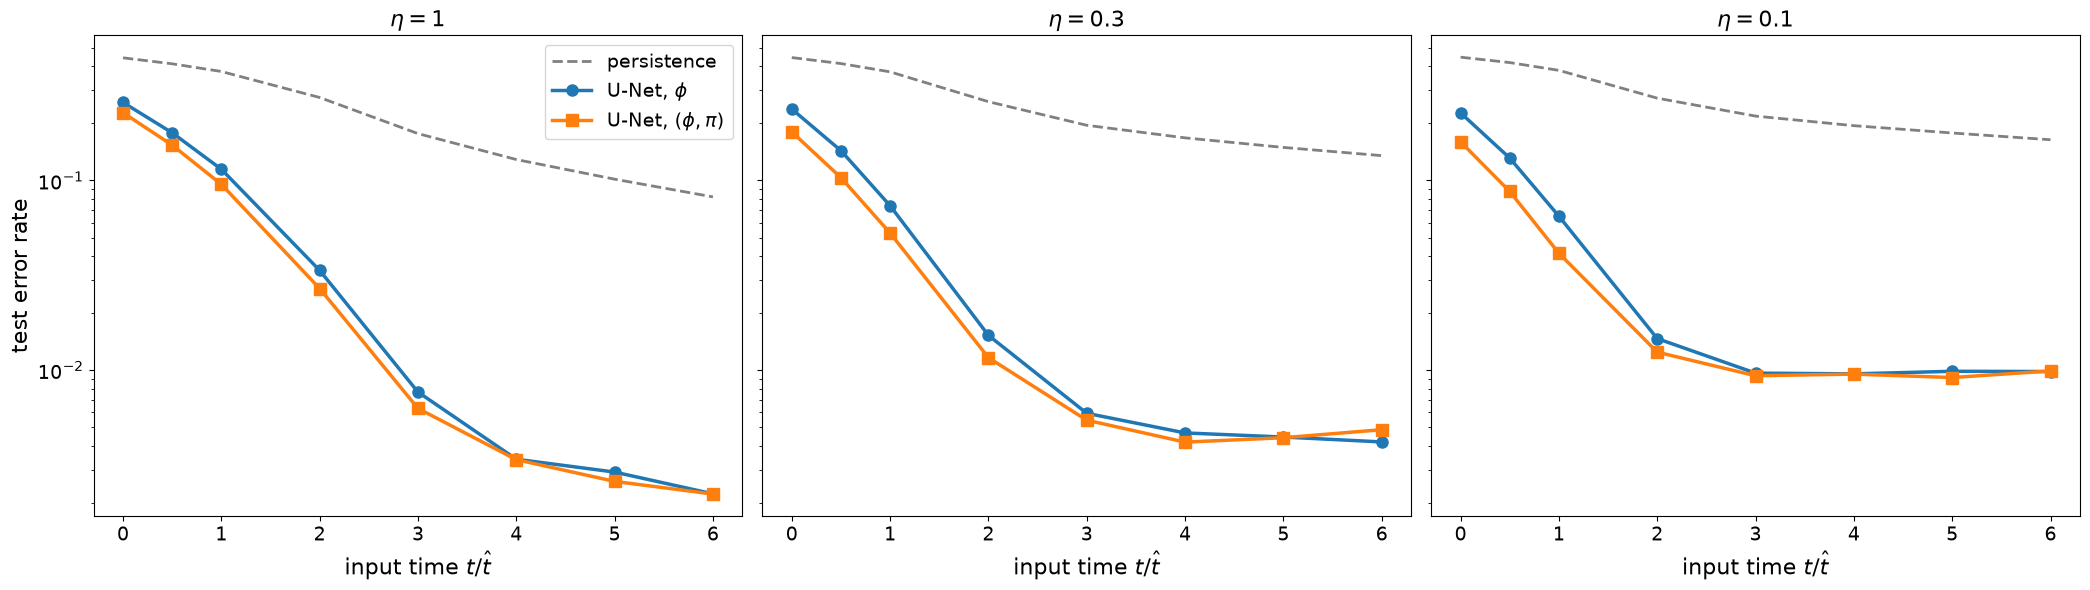

In [25]:
# ---- inputs ----
ETAS     = ["1", "0.3", "0.1"]
FONTSIZE = 16

fig, axes = plt.subplots(1, len(ETAS), figsize=(7 * len(ETAS), 6), sharey=True)

for ax, eta in zip(axes, ETAS):
    runs = {}
    for f in glob.glob(f"results_eta{eta}/t*.json"):
        r = json.load(open(f))
        runs.setdefault(r["t"], {})[r["channels"]] = r
    ts = sorted(runs)

    pers  = [1 - runs[t]["phi"]["baseline"]    for t in ts]
    e_phi = [1 - runs[t]["phi"]["test_acc"]    for t in ts]
    e_pi  = [1 - runs[t]["phi_pi"]["test_acc"] for t in ts]

    ax.semilogy(ts, pers,  "--", color="grey", lw=2, label="persistence")
    ax.semilogy(ts, e_phi, "o-", color="C0", lw=2.5, ms=8, label=r"U-Net, $\phi$")
    ax.semilogy(ts, e_pi,  "s-", color="C1", lw=2.5, ms=8, label=r"U-Net, $(\phi, \pi)$")
    ax.set_title(rf"$\eta = {eta}$", fontsize=FONTSIZE)
    ax.set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 2)

axes[0].set_ylabel("test error rate", fontsize=FONTSIZE)
axes[0].legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.savefig("error_phi_vs_phipi.png", dpi=150)
plt.show()